<span style="font-size:40px">Як пройтися мостами?</span>

<span style="font-size:20px">Визначити, чи можна на графі пройтися по кожному ребру по разу і повернутися в початкову точку</span>

**Постановка задачі**:  
Маємо острівну державу, яка має дуже амбітну команду пенсіонерів-пішоходів. Вони хочуть обходити всі мости в державі, але ненавидять повтори, тому лише по разу. При чому хочуть повернутись звідти, звідки вони вийшли. Разом з товаритвом картографів-математиків вони надають вам наступні дані:  
1. Назви островів
2. Для кожного острова список островів, із яким є пряме сполучення.
Наше завдання: визначити, чи можна прогулятися пенсіонерам таким маршрутом як вони хочуть, якщо так, то проілюструвати це проходження


<span style="font-size:20px">Математична модель</span>

У нашій моделі будемо розглядати острови як вершини неорієнтованого (зв'язного) графа, а мости між ними — як ребра між відповідними вершинами. Тобто задача зводиться до пошуку так званого ейлерового циклу у графі-мапі островів.

Для прикладу розглянемо карту клубу окультистів. 

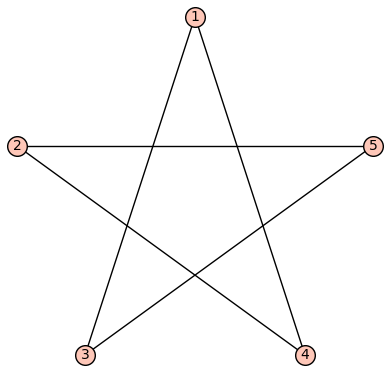

In [7]:
G=Graph({1:[4, 3], 2:[4, 5], 3:[1,5], 4:[2,1], 5:[2,3]})
G.show(layout="circular")

Очевидно, що пенсіонери по ньому б пройти могли.

Тепер розглянемо граф, по якому пройти не можна від острову некроманів

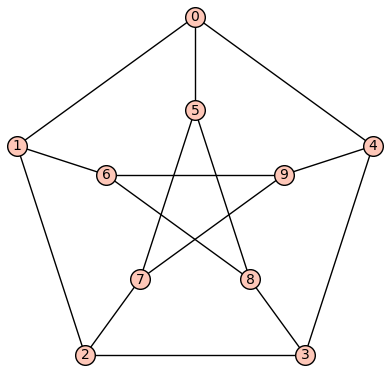

In [8]:
P = graphs.PetersenGraph()
P.show()

Можете спробувати, як би ви не ходили по ньому, ви не зможете пройти по кожному ребру як хочуть пенсіонери.

Справа в тому, що якщо ви вийдете з вершини з непарним степенем (кількість ребер, одним з кінців яких вона є), то ви в неї повернутися не зможете. Виходите одним ребром, повертаєтесь іншим, виходите третім. Через непарність ви завжди закінчуватимете на виході.  
    Аналогічно коли ви заходите: ви не зможете остаточно вийти.
    

Тобто критерієм пенсіонеропрохідності (ейлеровості) є степінь вершин: вони мають усі буди парними.

### Конкретна задача від пенсіонерів
Хоча карти островів окультистів і некромантів виглядають дуже цікаво, справжні острівні держави рідко виглядають так симетрично. Тож розглянема тепер нову мапу, яку нам надіслали найзвичайніші пенсіонери:

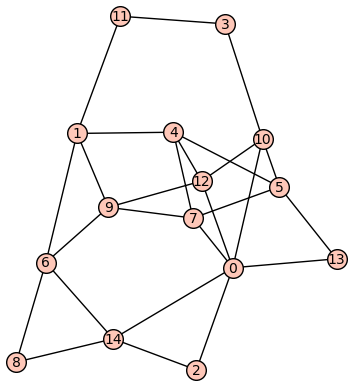

In [73]:
import numpy
array = numpy.loadtxt('letter_with_map.txt', dtype=int)
M = Graph(Matrix(array))
M.show(save_pos = True)

<span style="font-size:20px">Рішення завдання</span>

Спершу визначимо чи є граф ейлерівським:

In [3]:
if M.is_eulerian():
    print("Yay!")
else: print("Nope")

Yay!


Можемо писати пенсіонерам що так. Тепер шукаємо конкретний шлях:

In [4]:
circuit = M.eulerian_circuit()
path = [edge[0] for edge in circuit] + [circuit[-1][1]]
print(path)


[0, 13, 5, 10, 12, 9, 7, 5, 4, 12, 0, 10, 3, 11, 1, 9, 6, 14, 8, 6, 1, 4, 7, 0, 14, 2, 0]


Проілюструємо проходження цього шляху, зафарбовуючи пройдені мости в чорний:

In [74]:

pos = M.get_pos()
frames = [M.plot(pos=pos, figsize=[6,4], edge_thickness=3,  
                 edge_colors = {"black": circuit[0:i], "blue": circuit[i:len(circuit)]}) for i in range(len(circuit)+1)]

@interact
def my_graph_animation(frame_index=slider(0, len(frames)-1, label="Frame")):
    show(frames[frame_index])


Interactive function <function my_graph_animation at 0x711967c31170> with 1 widget
  frame_index: TransformIntSlider(value=0, description='Frame', max=26)